# Imports

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.preprocessing import PowerTransformer, QuantileTransformer

## Utils

# Loading Dataset

In [2]:
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

In [3]:
df_train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
df_train.tail()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
439135,439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0
439136,439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0
439137,439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0
439138,439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0
439139,439139,D714,HARD,Miami Grand Prix,2023,0,49,2,32.0,1,91.691,-0.123,-15.828,0.859649,0.0,0.0


## Columns

In [5]:
df_train.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='str')

In [6]:
df_test.columns

Index(['id', 'Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber',
       'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change'],
      dtype='str')

## Data Dimension

In [7]:
df_train.shape

(439140, 16)

In [8]:
df_test.shape

(188165, 15)

## Check NA

In [9]:
df_train.isna().mean()

id                        0.0
Driver                    0.0
Compound                  0.0
Race                      0.0
Year                      0.0
PitStop                   0.0
LapNumber                 0.0
Stint                     0.0
TyreLife                  0.0
Position                  0.0
LapTime (s)               0.0
LapTime_Delta             0.0
Cumulative_Degradation    0.0
RaceProgress              0.0
Position_Change           0.0
PitNextLap                0.0
dtype: float64

In [10]:
df_test.isna().mean()

id                        0.0
Driver                    0.0
Compound                  0.0
Race                      0.0
Year                      0.0
PitStop                   0.0
LapNumber                 0.0
Stint                     0.0
TyreLife                  0.0
Position                  0.0
LapTime (s)               0.0
LapTime_Delta             0.0
Cumulative_Degradation    0.0
RaceProgress              0.0
Position_Change           0.0
dtype: float64

# Exploratory Data Analysis

## Univariate Data Analysis

In [11]:
df_train['Driver'].value_counts(1)

Driver
MAS     0.003830
RAI     0.003801
BAR     0.003771
BUT     0.003769
FIS     0.003760
          ...   
D711    0.000002
D755    0.000002
D731    0.000002
D716    0.000002
D714    0.000002
Name: proportion, Length: 887, dtype: float64

In [12]:
df_train['Compound'].value_counts(1) # mapping = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTERMEDIATE': 4, 'WET': 5}

Compound
MEDIUM          0.480806
HARD            0.388300
SOFT            0.088227
INTERMEDIATE    0.039582
WET             0.003086
Name: proportion, dtype: float64

In [13]:
df_train['Race'].value_counts(1)

Race
Dutch Grand Prix             0.055704
Mexico City Grand Prix       0.053905
Pre-Season Testing           0.051218
Hungarian Grand Prix         0.051193
Monaco Grand Prix            0.049048
Canadian Grand Prix          0.048768
Austrian Grand Prix          0.048329
Spanish Grand Prix           0.046643
Italian Grand Prix           0.045211
Bahrain Grand Prix           0.044485
Singapore Grand Prix         0.043175
Miami Grand Prix             0.042948
Australian Grand Prix        0.041914
Saudi Arabian Grand Prix     0.041242
United States Grand Prix     0.041092
Abu Dhabi Grand Prix         0.037407
Emilia Romagna Grand Prix    0.035258
British Grand Prix           0.035030
Qatar Grand Prix             0.031464
Japanese Grand Prix          0.029355
Las Vegas Grand Prix         0.028417
Azerbaijan Grand Prix        0.027613
São Paulo Grand Prix         0.026181
Belgian Grand Prix           0.020499
Chinese Grand Prix           0.016648
French Grand Prix            0.007253
Name: p

In [14]:
df_train['Year'].value_counts()

Year
2023    136147
2024    127110
2025     92894
2022     82989
Name: count, dtype: int64

In [15]:
df_train['PitStop'].value_counts(1)

PitStop
0    0.863882
1    0.136118
Name: proportion, dtype: float64

In [30]:
pt = QuantileTransformer(output_distribution='normal')
df_train['lap_number_power'] = pt.fit_transform(df_train[['LapNumber']])

<Axes: ylabel='Frequency'>

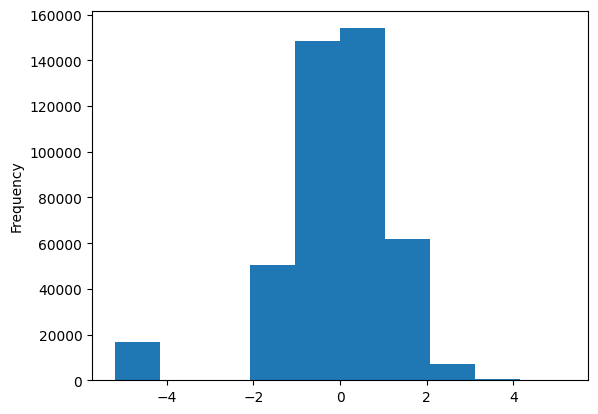

In [32]:
df_train['lap_number_power'].plot.hist()

<Axes: >

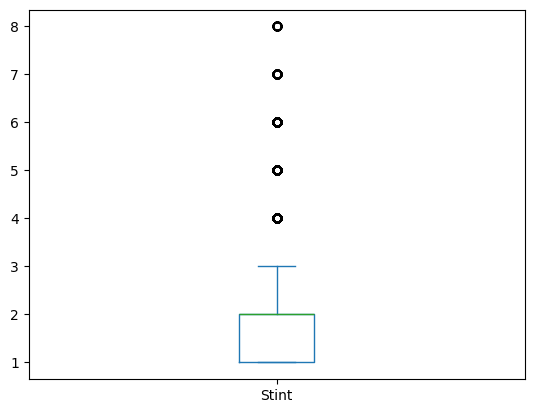

In [27]:
df_train['Stint'].plot.box() # Stint – Tire stint number

<Axes: >

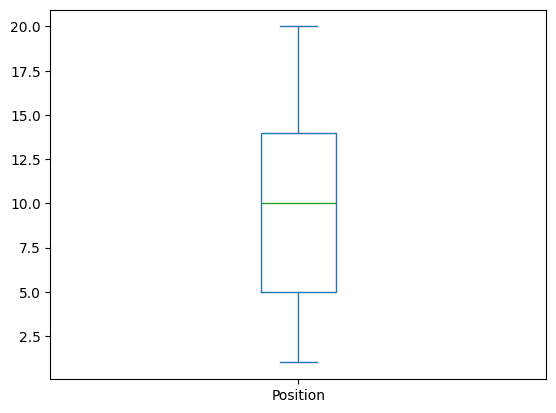

In [29]:
df_train['Position'].plot.box() # Driver’s position on that lap

<Axes: >

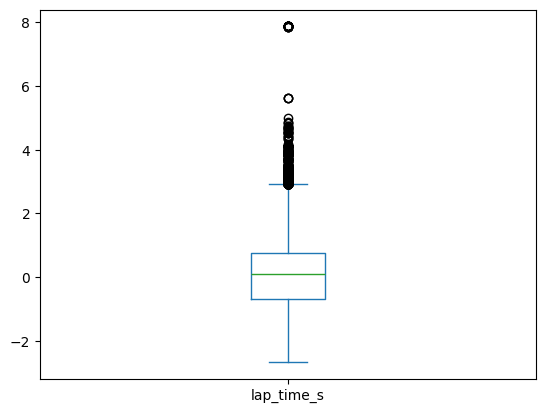

In [37]:
pt = PowerTransformer()
df_train['lap_time_s'] = pt.fit_transform(df_train[['LapTime (s)']])
df_train['lap_time_s'].plot.box()

<Axes: >

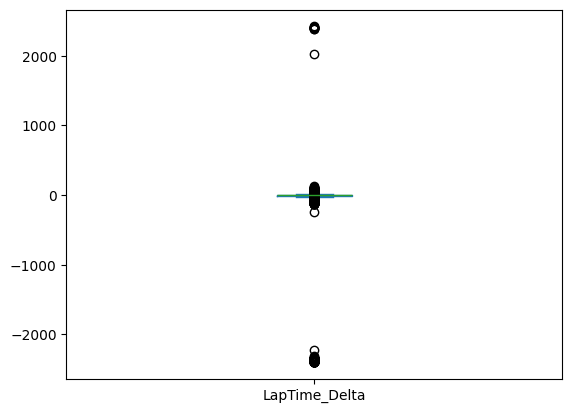

In [34]:
df_train['LapTime_Delta'].plot.box() # LapTime_Delta – Change in lap time from previous lap

<Axes: >

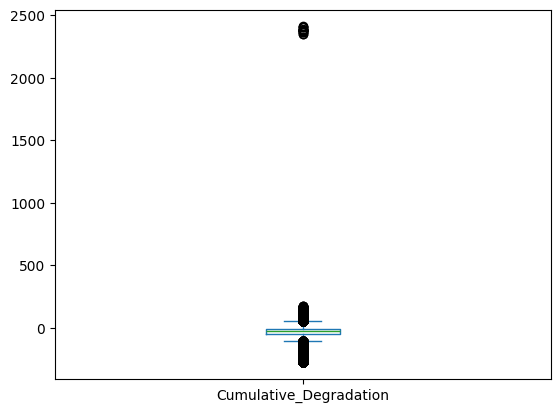

In [36]:
df_train['Cumulative_Degradation'].plot.box() # Accumulated tire performance drop

<Axes: >

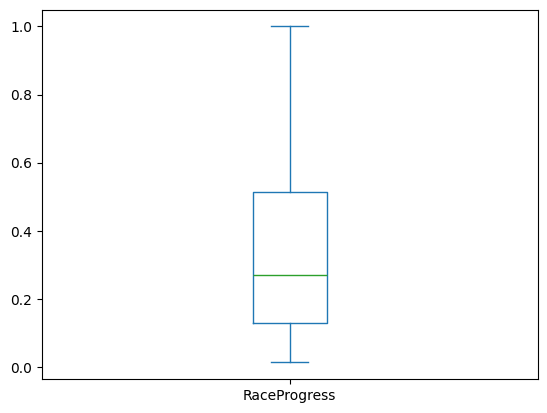

In [39]:
df_train['RaceProgress'].plot.box() # Fraction of race completed (0 → 1)

<Axes: >

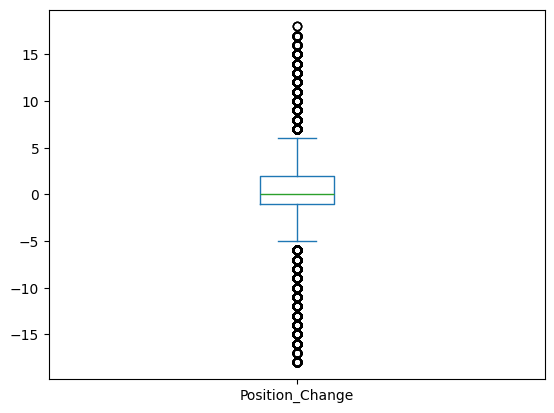

In [38]:
df_train['Position_Change'].plot.box() # Position gain/loss compared to previous lap

## Bivariate Data Analysis

In [40]:
df_train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [46]:
df_train.groupby('Driver')['PitNextLap'].mean().sort_values(ascending=False)

Driver
VET     0.565460
MSC     0.473239
HAD     0.462069
STR     0.427451
ANT     0.410072
          ...   
D590    0.000000
D589    0.000000
D588    0.000000
D587    0.000000
D598    0.000000
Name: PitNextLap, Length: 887, dtype: float64

In [47]:
df_train.groupby('Compound')['PitNextLap'].mean().sort_values(ascending=False)

Compound
HARD            0.327537
SOFT            0.193475
INTERMEDIATE    0.152284
MEDIUM          0.101131
WET             0.025092
Name: PitNextLap, dtype: float64

In [49]:
df_train.groupby('Year')['PitNextLap'].mean().sort_values(ascending=False)

Year
2024    0.295319
2025    0.284389
2022    0.266505
2023    0.009607
Name: PitNextLap, dtype: float64

<Axes: xlabel='Cumulative_Degradation', ylabel='RaceProgress'>

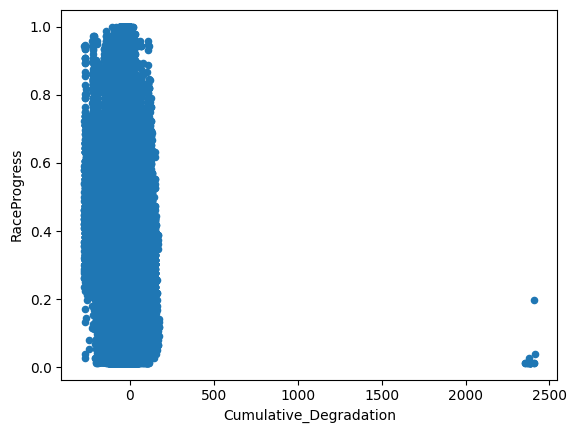

In [52]:
df_train[['Cumulative_Degradation', 'RaceProgress']].plot.scatter(x='Cumulative_Degradation', y='RaceProgress')

<Axes: xlabel='RaceProgress', ylabel='LapTime (s)'>

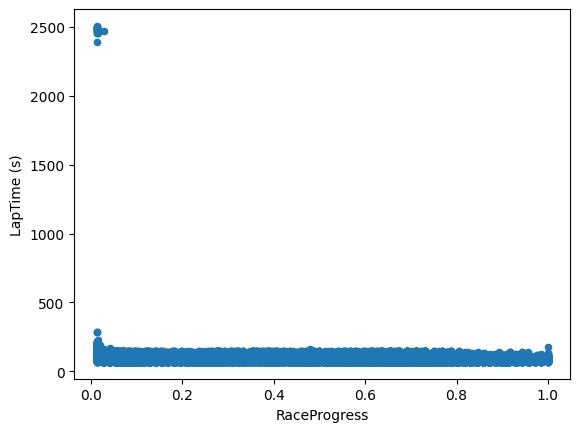

In [53]:
df_train.plot.scatter(x='RaceProgress', y='LapTime (s)')

## Multivatiate Data Analysis

In [54]:
df_train.select_dtypes(exclude='object').corr()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
id,1.000000,0.002153,-0.000214,0.000852,0.002810,-0.000167,0.001732,0.003059,0.000116,-0.001201,0.000925,0.000015,-0.000097
Year,0.002153,1.000000,0.090767,0.008556,-0.055644,0.041472,0.039931,-0.047048,-0.011863,0.036667,-0.068874,0.008429,0.125267
PitStop,-0.000214,0.090767,1.000000,0.111431,0.143869,-0.134678,0.093536,-0.000437,-0.008458,-0.088052,0.059177,-0.107659,0.048567
LapNumber,0.000852,0.008556,0.111431,1.000000,0.724390,0.648408,0.001951,-0.128485,0.031275,-0.173135,0.964539,0.010347,0.267057
Stint,0.002810,-0.055644,0.143869,0.724390,1.000000,0.157733,0.151200,-0.068869,0.017193,-0.118171,0.710020,-0.014225,0.198193
TyreLife,-0.000167,0.041472,-0.134678,0.648408,0.157733,1.000000,-0.120744,-0.133304,0.035947,-0.111742,0.622660,0.052309,0.273510
Position,0.001732,0.039931,0.093536,0.001951,0.151200,-0.120744,1.000000,0.017899,-0.012633,-0.026649,0.006937,-0.316446,0.021348
LapTime (s),0.003059,-0.047048,-0.000437,-0.128485,-0.068869,-0.133304,0.017899,1.000000,0.138818,0.205705,-0.094317,-0.002352,-0.034096
LapTime_Delta,0.000116,-0.011863,-0.008458,0.031275,0.017193,0.035947,-0.012633,0.138818,1.000000,0.053713,0.036777,0.005837,-0.004946
Cumulative_Degradation,-0.001201,0.036667,-0.088052,-0.173135,-0.118171,-0.111742,-0.026649,0.205705,0.053713,1.000000,-0.137938,-0.000067,-0.167401
